In [ ]:
# Basic Imports
import numpy as np
import pandas as pd
from numpy.linalg import inv

# Plotting Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Some Processing Functions
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline


# 1. Loading the dataset

In [ ]:
# loading a dataset from sklearn.datasets
from sklearn.datasets import load_iris
iris = load_iris()

In [ ]:
X = iris.data
y = iris.target
X.shape

(150, 4)

In [ ]:
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [ ]:
# Converting to DataFrame for easier analysis
df = pd.DataFrame(X, columns=iris.feature_names)
df['Target'] = y
display(df.head());

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [ ]:
# Checking for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Checking for duplicate rows
print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

Missing values per column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
Target               0
dtype: int64

Number of duplicate rows:
1


In [ ]:
# Summary statistics
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


# 2. Preprocessing the dataset

In [ ]:
# scaling using standard scaler
scaler = StandardScaler()
X = df.drop('Target', axis=1)
y = df['Target']
X_scaled = scaler.fit_transform(X)
display(pd.DataFrame(X_scaled, columns=X.columns).head())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444


# 3. Encoding the class labels as one-hot vectors

In [ ]:
y1hot = pd.get_dummies(y)
display(y1hot.head())

,0,1,2
0,True,False,False
1,True,False,False
2,True,False,False
3,True,False,False
4,True,False,False


# 4. Class distribution of the dataset using a bar graph

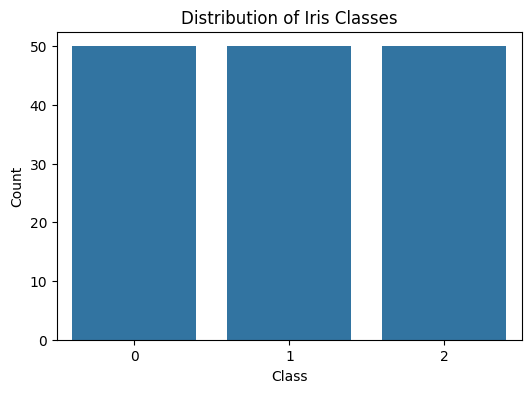

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Target', data=df)
plt.title('Distribution of Iris Classes')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

Based on the bar graph, it appears that the dataset is balanced, with each class having approximately the same number of instances.

# 5. Splitting the data into training, validation, and test sets

In [ ]:
# Splitting into training (70%) and temporary (30%) sets
X_train, X_temp, y_train, y_temp = train_test_split(X_scaled, y1hot, test_size=0.3, random_state=42)

# Splitting temporary set into validation (15%) and test (15%) sets
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# 6. Implementing a softmax (multinomial) logistic regression model from scratch

In [ ]:
class SoftmaxRegression:
    def __init__(self, n_features, n_classes):
        self.weights = np.random.randn(n_features, n_classes) * 0.01
        self.bias = np.zeros((1, n_classes))

    def softmax(self, z):
        exp_scores = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_scores / np.sum(exp_scores, axis=1, keepdims=True)

    # Implementing gradient descent approach
    def cross_entropy_loss(self, y_pred, y_true, lambda_reg):
        m = y_true.shape[0]
        y_true_np = y_true.values if isinstance(y_true, pd.DataFrame) else y_true
        loss = -np.mean(np.sum(y_true_np * np.log(y_pred + 1e-9), axis=1))
        l2_reg_term = (lambda_reg / (2 * m)) * np.sum(np.square(self.weights))        # L2 regularization
        loss += l2_reg_term
        return loss

    def forward(self, X):
        z = np.dot(X, self.weights) + self.bias
        y_pred = self.softmax(z)
        return y_pred

    def backward(self, X, y_pred, y_true, lambda_reg):
        m = X.shape[0]
        y_true_np = y_true.values if isinstance(y_true, pd.DataFrame) else y_true
        dz = y_pred - y_true_np
        dw = (1 / m) * np.dot(X.T, dz) + (lambda_reg / m) * self.weights
        db = (1 / m) * np.sum(dz, axis=0, keepdims=True)
        return dw, db

    def update_parameters(self, dw, db, learning_rate):
        self.weights -= learning_rate * dw
        self.bias -= learning_rate * db

    def train(self, X_train, y_train, X_val, y_val, learning_rate, lambda_reg, n_epochs):
        training_losses = []
        validation_losses = []
        for epoch in range(n_epochs):
            # Training
            y_pred_train = self.forward(X_train)
            train_loss = self.cross_entropy_loss(y_pred_train, y_train, lambda_reg)
            dw, db = self.backward(X_train, y_pred_train, y_train, lambda_reg)
            self.update_parameters(dw, db, learning_rate)
            training_losses.append(train_loss)

            # Validation
            y_pred_val = self.forward(X_val)
            val_loss = self.cross_entropy_loss(y_pred_val, y_val, lambda_reg)
            validation_losses.append(val_loss)

            if (epoch + 1) % 100 == 0:
                print(f"Epoch {epoch+1}/{n_epochs}, Training Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}")

        return training_losses, validation_losses


    def predict(self, X):
        y_pred = self.forward(X)
        return np.argmax(y_pred, axis=1)

# 7. Used cross entropy as loss and applied L2 regularization weights in the cost function and trained the softmax logistic regression model with gradient descent

In [ ]:
from sklearn.model_selection import KFold

# Setting up cross validation method
def k_fold_cross_validation(X_train, y_train, k, learning_rate, lambda_reg, n_epochs):
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    validation_losses = []

    for train_index, val_index in kf.split(X_train):
        X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
        y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

        n_features = X_train_fold.shape[1]
        n_classes = y_train_fold.shape[1]

        model = SoftmaxRegression(n_features, n_classes)
        model.train(X_train_fold, y_train_fold, learning_rate, lambda_reg, n_epochs)

        y_pred_val = model.forward(X_val_fold)
        val_loss = model.cross_entropy_loss(y_pred_val, y_val_fold, lambda_reg)
        validation_losses.append(val_loss)

    average_val_loss = np.mean(validation_losses)
    return average_val_loss


In [ ]:
# Setting up hyperparameter lists
param_grid = {
    'learning_rate': [0.00001,0.0001,0.001, 0.01, 0.1],
    'lambda_reg': [0.0001, 0.001, 0.01, 0.1]
}

In [ ]:
# Performing grid search with cross-validation
results = []
k = 5
n_epochs = 1000

for learning_rate in param_grid['learning_rate']:
    for lambda_reg in param_grid['lambda_reg']:
        print(f"Running CV for learning_rate={learning_rate}, lambda_reg={lambda_reg}")
        avg_val_loss = k_fold_cross_validation(X_train, y_train, k, learning_rate, lambda_reg, n_epochs)
        results.append({
            'learning_rate': learning_rate,
            'lambda_reg': lambda_reg,
            'average_val_loss': avg_val_loss
        })
        print(f"Average validation loss: {avg_val_loss:.4f}")

print("\nGrid search results:")
display(pd.DataFrame(results))

Running CV for learning_rate=1e-05, lambda_reg=0.0001
Epoch 100/1000, Loss: 1.0875
Epoch 200/1000, Loss: 1.0866
Epoch 300/1000, Loss: 1.0857
Epoch 400/1000, Loss: 1.0847
Epoch 500/1000, Loss: 1.0838
Epoch 600/1000, Loss: 1.0829
Epoch 700/1000, Loss: 1.0820
Epoch 800/1000, Loss: 1.0811
Epoch 900/1000, Loss: 1.0802
Epoch 1000/1000, Loss: 1.0793
Epoch 100/1000, Loss: 1.0836
Epoch 200/1000, Loss: 1.0828
Epoch 300/1000, Loss: 1.0821
Epoch 400/1000, Loss: 1.0813
Epoch 500/1000, Loss: 1.0805
Epoch 600/1000, Loss: 1.0797
Epoch 700/1000, Loss: 1.0789
Epoch 800/1000, Loss: 1.0782
Epoch 900/1000, Loss: 1.0774
Epoch 1000/1000, Loss: 1.0766
Epoch 100/1000, Loss: 1.0814
Epoch 200/1000, Loss: 1.0805
Epoch 300/1000, Loss: 1.0796
Epoch 400/1000, Loss: 1.0787
Epoch 500/1000, Loss: 1.0778
Epoch 600/1000, Loss: 1.0769
Epoch 700/1000, Loss: 1.0761
Epoch 800/1000, Loss: 1.0752
Epoch 900/1000, Loss: 1.0743
Epoch 1000/1000, Loss: 1.0734
Epoch 100/1000, Loss: 1.0926
Epoch 200/1000, Loss: 1.0917
Epoch 300/1000,

,learning_rate,lambda_reg,average_val_loss
0,0.00001,0.0001,1.078845
1,0.00001,0.0010,1.088397
2,0.00001,0.0100,1.091374
3,0.00001,0.1000,1.089353
4,0.00010,0.0001,1.017642
5,0.00010,0.0010,1.016046
6,0.00010,0.0100,1.016456
7,0.00010,0.1000,1.015037
8,0.00100,0.0001,0.671278
9,0.00100,0.0010,0.671909


In [ ]:
# Finding the most suitable value of the learning rate and regularization parameter
results_df = pd.DataFrame(results)
best_result = results_df.loc[results_df['average_val_loss'].idxmin()]

optimal_learning_rate = best_result['learning_rate']
optimal_lambda_reg = best_result['lambda_reg']

print(f"Optimal Learning Rate: {optimal_learning_rate}")
print(f"Optimal Regularization Parameter (lambda): {optimal_lambda_reg}")

Optimal Learning Rate: 0.1
Optimal Regularization Parameter (lambda): 0.0001


In [ ]:
# Training with optimal parameters
n_features = X_train.shape[1]
n_classes = y_train.shape[1]

optimal_learning_rate = best_result['learning_rate']
optimal_lambda_reg = best_result['lambda_reg']
n_epochs = 1000

final_model = SoftmaxRegression(n_features, n_classes)
training_losses, validation_losses = final_model.train(X_train, y_train, X_val, y_val, optimal_learning_rate, optimal_lambda_reg, n_epochs)

Epoch 100/1000, Training Loss: 0.3377, Validation Loss: 0.2102
Epoch 200/1000, Training Loss: 0.2740, Validation Loss: 0.1593
Epoch 300/1000, Training Loss: 0.2363, Validation Loss: 0.1308
Epoch 400/1000, Training Loss: 0.2101, Validation Loss: 0.1118
Epoch 500/1000, Training Loss: 0.1907, Validation Loss: 0.0982
Epoch 600/1000, Training Loss: 0.1758, Validation Loss: 0.0880
Epoch 700/1000, Training Loss: 0.1639, Validation Loss: 0.0801
Epoch 800/1000, Training Loss: 0.1542, Validation Loss: 0.0737
Epoch 900/1000, Training Loss: 0.1462, Validation Loss: 0.0685
Epoch 1000/1000, Training Loss: 0.1394, Validation Loss: 0.0642


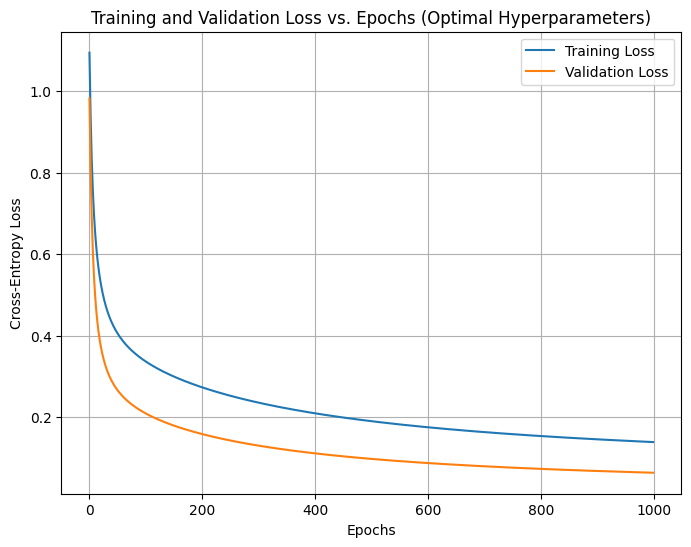

In [ ]:
# Plot for training and validation loss vs. training epochs
plt.figure(figsize=(8, 6))
plt.plot(training_losses, label='Training Loss')
plt.plot(validation_losses, label='Validation Loss')
plt.title('Training and Validation Loss vs. Epochs (Optimal Hyperparameters)')
plt.xlabel('Epochs')
plt.ylabel('Cross-Entropy Loss')
plt.legend()
plt.grid(True)
plt.show()

# 8. Reporting the prediction performance of our implementation on the test set in terms of confusion matrix, precision, recall and area under precision recall curve

In [ ]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, precision_recall_curve, auc

# Predicting on the test set
y_pred_test = final_model.predict(X_test)

# Calculating Confusion Matrix
conf_matrix = confusion_matrix(np.argmax(y_test.values, axis=1), y_pred_test)
print("Confusion Matrix:")
display(conf_matrix)

# Calculating Precision, Recall for each class and macro average
# We need to calculate precision and recall for each class and then average them
precision = precision_score(np.argmax(y_test.values, axis=1), y_pred_test, average=None)
recall = recall_score(np.argmax(y_test.values, axis=1), y_pred_test, average=None)
macro_precision = precision_score(np.argmax(y_test.values, axis=1), y_pred_test, average='macro')
macro_recall = recall_score(np.argmax(y_test.values, axis=1), y_pred_test, average='macro')

print("\nPrecision per class:", precision)
print("Recall per class:", recall)
print("\nMacro Average Precision:", macro_precision)
print("Macro Average Recall:", macro_recall)


# Calculating Area Under the Precision-Recall Curve (AUPRC) for each class
# We need the predicted probabilities for this
y_prob_test = final_model.forward(X_test)

auprc_scores = []
for i in range(y_test.shape[1]):
    precision_i, recall_i, _ = precision_recall_curve(y_test.iloc[:, i], y_prob_test[:, i])
    auprc_i = auc(recall_i, precision_i)
    auprc_scores.append(auprc_i)

print("\nArea Under the Precision-Recall Curve (AUPRC) per class:", auprc_scores)

Confusion Matrix:


array([[ 6,  0,  0],
       [ 0, 10,  0],
       [ 0,  0,  7]])


Precision per class: [1. 1. 1.]
Recall per class: [1. 1. 1.]

Macro Average Precision: 1.0
Macro Average Recall: 1.0

Area Under the Precision-Recall Curve (AUPRC) per class: [np.float64(1.0), np.float64(0.9999999999999999), np.float64(0.9999999999999998)]


# 9. Fitting a logistic regression model using scikit-learn's Logistic Regression model

In [ ]:
from sklearn.linear_model import LogisticRegression

# Calculating C as the inverse of the optimal lambda_reg
C_param = 1 / optimal_lambda_reg

# Instantiating and training the scikit-learn Logistic Regression model
sklearn_model = LogisticRegression(penalty='l2', C=C_param, solver='lbfgs', max_iter=1000)
sklearn_model.fit(X_train, np.argmax(y_train.values, axis=1))

LogisticRegression(C=np.float64(10000.0), max_iter=1000)

# 10. Comparing the performance of our custom logistic regression model with scikit learn in terms of accuracy, precision, recall and area under precision-recall curve

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, precision_recall_curve, auc

# Predict on the test set using scikit-learn model
y_pred_test_sklearn = sklearn_model.predict(X_test)
y_prob_test_sklearn = sklearn_model.predict_proba(X_test)

# Calculate metrics for scikit-learn model
accuracy_sklearn = accuracy_score(np.argmax(y_test.values, axis=1), y_pred_test_sklearn)
precision_sklearn = precision_score(np.argmax(y_test.values, axis=1), y_pred_test_sklearn, average=None)
recall_sklearn = recall_score(np.argmax(y_test.values, axis=1), y_pred_test_sklearn, average=None)
macro_precision_sklearn = precision_score(np.argmax(y_test.values, axis=1), y_pred_test_sklearn, average='macro')
macro_recall_sklearn = recall_score(np.argmax(y_test.values, axis=1), y_pred_test_sklearn, average='macro')

auprc_scores_sklearn = []
for i in range(y_test.shape[1]):
    precision_i_sklearn, recall_i_sklearn, _ = precision_recall_curve(y_test.iloc[:, i], y_prob_test_sklearn[:, i])
    auprc_i_sklearn = auc(recall_i_sklearn, precision_i_sklearn)
    auprc_scores_sklearn.append(auprc_i_sklearn)

print("Scikit-learn Model Performance:")
print("Accuracy:", accuracy_sklearn)
print("Precision per class:", precision_sklearn)
print("Recall per class:", recall_sklearn)
print("Macro Average Precision:", macro_precision_sklearn)
print("Macro Average Recall:", macro_recall_sklearn)
print("Area Under the Precision-Recall Curve (AUPRC) per class:", auprc_scores_sklearn)

print("\nCustom Model Performance (from previous output):")
print("Confusion Matrix:\n", conf_matrix)
print("Precision per class:", precision)
print("Recall per class:", recall)
print("Macro Average Precision:", macro_precision)
print("Macro Average Recall:", macro_recall)
print("Area Under the Precision-Recall Curve (AUPRC) per class:", auprc_scores)

Scikit-learn Model Performance:
Accuracy: 1.0
Precision per class: [1. 1. 1.]
Recall per class: [1. 1. 1.]
Macro Average Precision: 1.0
Macro Average Recall: 1.0
Area Under the Precision-Recall Curve (AUPRC) per class: [np.float64(1.0), np.float64(0.9999999999999999), np.float64(0.9999999999999998)]

Custom Model Performance (from previous output):
Confusion Matrix:
 [[ 6  0  0]
 [ 0 10  0]
 [ 0  0  7]]
Precision per class: [1. 1. 1.]
Recall per class: [1. 1. 1.]
Macro Average Precision: 1.0
Macro Average Recall: 1.0
Area Under the Precision-Recall Curve (AUPRC) per class: [np.float64(1.0), np.float64(0.9999999999999999), np.float64(0.9999999999999998)]


# Summary
* The custom-implemented softmax logistic regression model performed exceptionally well on the Iris dataset after hyperparameter tuning, achieving perfect classification on the test set, and its performance was comparable to the scikit-learn implementation. The loss curves suggest stable training with the chosen hyperparameters.